
Analyze sales data to identify:
- Which category gives maximum profit?
- Which region is underperforming?
- Where business is losing money?
> Add blockquote



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df['Profit Ratio'] = df['Profit'] / df['Sales']
df['Month'] = pd.to_datetime(df['Order Date']).dt.month

In [6]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217


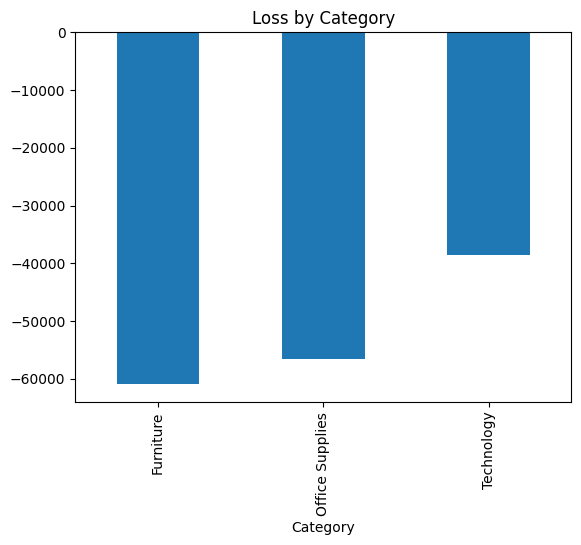

In [7]:
loss = df[df['Profit'] < 0]

loss.groupby('Category')['Profit'].sum().plot(kind='bar')
plt.title("Loss by Category")
plt.show()

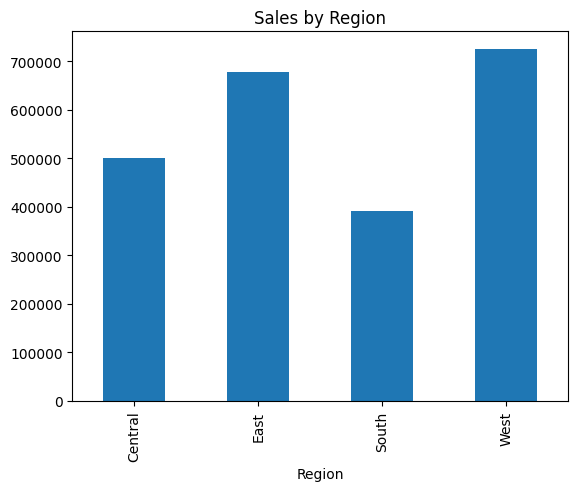

In [8]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

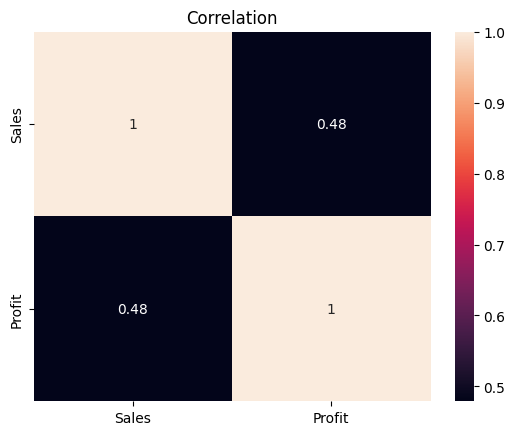

In [9]:
sns.heatmap(df[['Sales','Profit']].corr(), annot=True)
plt.title("Correlation")
plt.show()

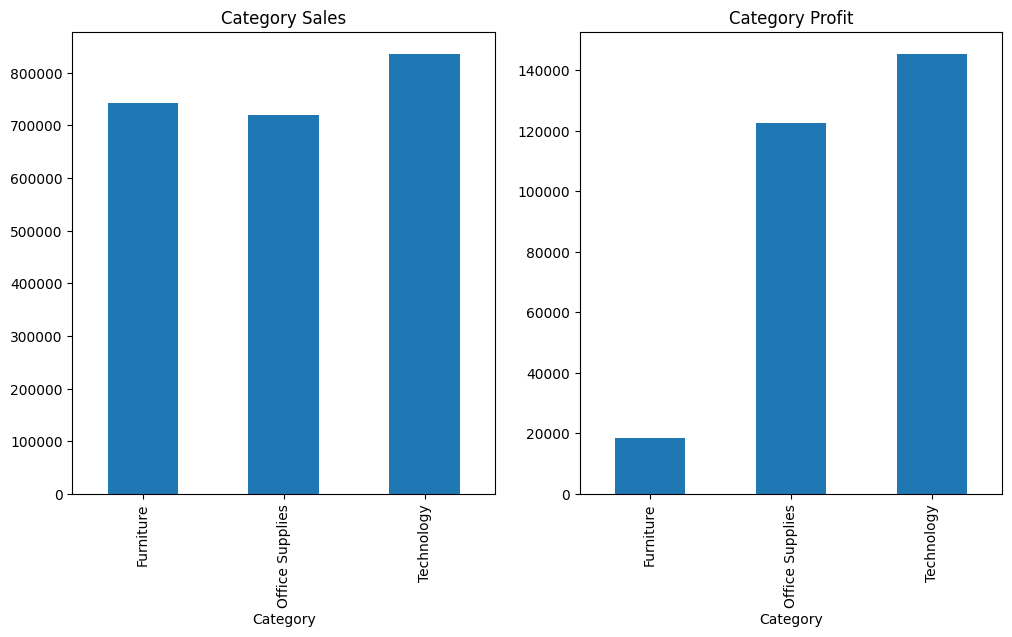

In [10]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Category Sales")

plt.subplot(1,2,2)
df.groupby('Category')['Profit'].sum().plot(kind='bar')
plt.title("Category Profit")

plt.show()

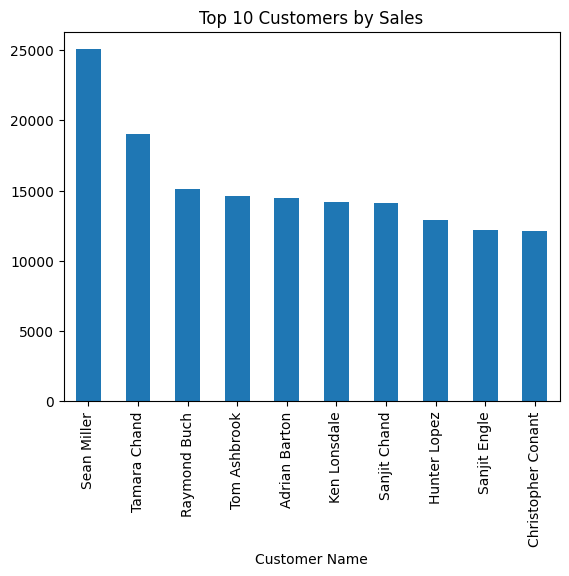

In [11]:
customer_sales = df.groupby('Customer Name')['Sales'].sum()

top_customers = customer_sales.sort_values(ascending=False).head(10)

plt.figure()
top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Sales")
plt.show()

In [12]:
df['Profit Margin (%)'] = (df['Profit'] / df['Sales']) * 100

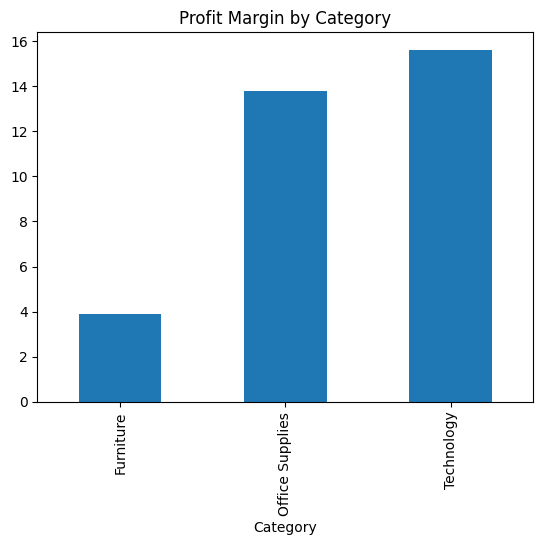

In [13]:
df.groupby('Category')['Profit Margin (%)'].mean().plot(kind='bar')
plt.title("Profit Margin by Category")
plt.show()

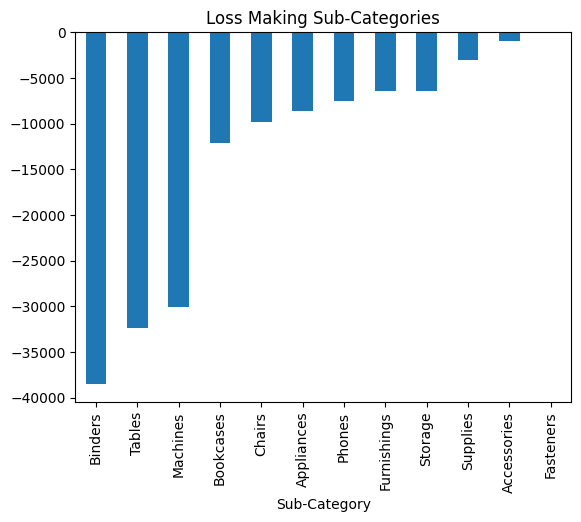

In [14]:
loss_df = df[df['Profit'] < 0]

loss_df.groupby('Sub-Category')['Profit'].sum().sort_values().plot(kind='bar')
plt.title("Loss Making Sub-Categories")
plt.show()

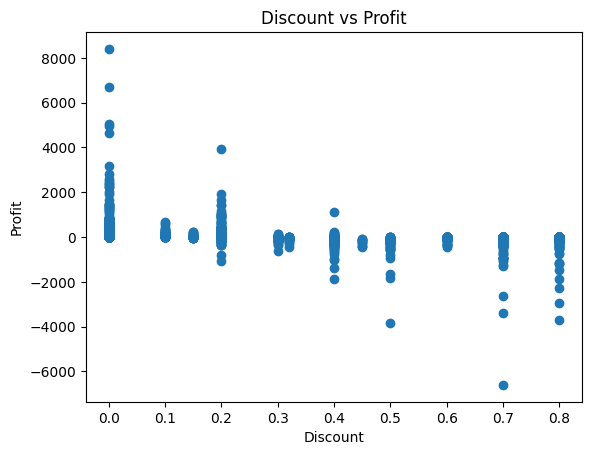

In [15]:
plt.figure()
plt.scatter(df['Discount'], df['Profit'])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

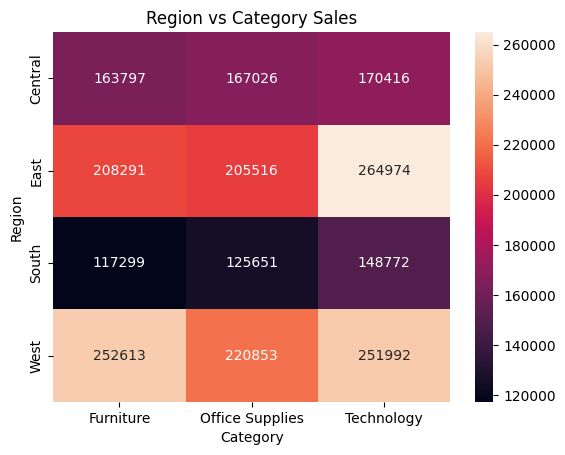

In [16]:
pivot = df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')

import seaborn as sns
sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title("Region vs Category Sales")
plt.show()

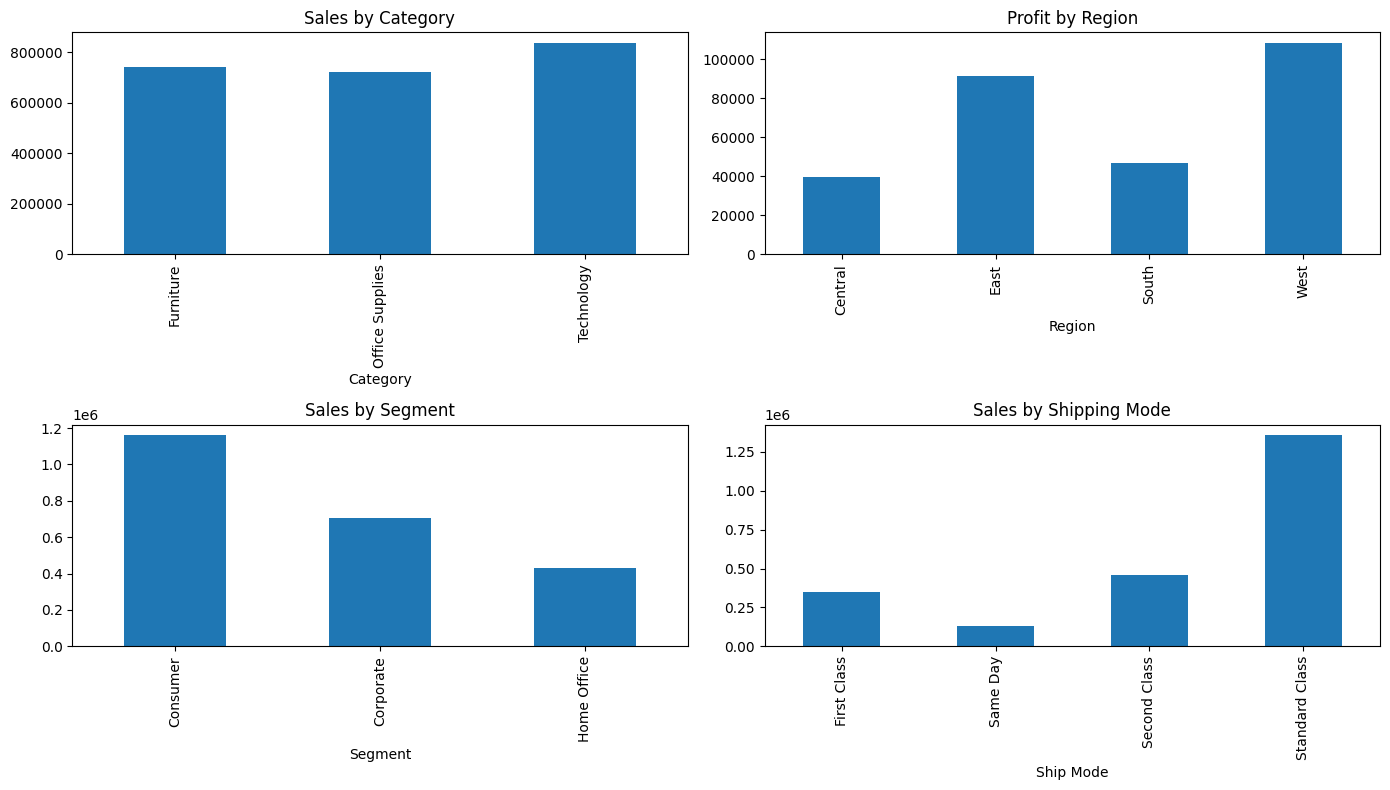

In [17]:
plt.figure(figsize=(14,8))

plt.subplot(2,2,1)
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")

plt.subplot(2,2,2)
df.groupby('Region')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Region")

plt.subplot(2,2,3)
df.groupby('Segment')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Segment")

plt.subplot(2,2,4)
df.groupby('Ship Mode')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Shipping Mode")

plt.tight_layout()
plt.show()

In [18]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')

monthly = df.groupby('Month')['Sales'].sum()
monthly.index = monthly.index.to_timestamp()

In [19]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
X = np.arange(len(monthly)).reshape(-1,1)
y = monthly.values

# Train model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [20]:
future = np.arange(len(monthly)+6).reshape(-1,1)
pred = model.predict(future)

/tmp/ipykernel_5530/4046533115.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=monthly.index[-1], periods=6, freq='M')


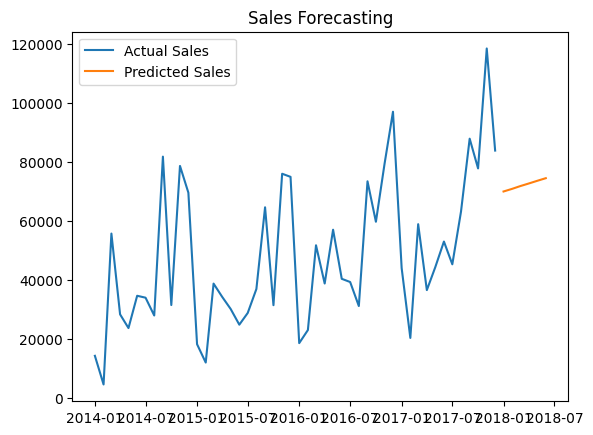

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly.index, y, label="Actual Sales")

future_dates = pd.date_range(start=monthly.index[-1], periods=6, freq='M')
plt.plot(future_dates, pred[-6:], label="Predicted Sales")

plt.legend()
plt.title("Sales Forecasting")
plt.show()

- Sales expected to increase/decrease in upcoming months
- Business should prepare inventory accordingly
- Focus on high-performing categories for growth